# Checkout A/B Test — Statistical Hypothesis Testing
1. Hypothesis formulation (H0 / H1)
2. Sample size, conversion rate calculation
3. Two-Sample Z-Test & Chi-Square Test
4. p-value, confidence intervals, effect size
5. Executive decision memo

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import (proportions_ztest, proportion_confint,
                                           confint_proportions_2indep, proportion_effectsize)
from statsmodels.stats.power import NormalIndPower

np.random.seed(42)

## 1. Hypothesis Formulation

- **H0 (Null):** p_B = p_A — the redesigned checkout (Variant) has the same conversion rate as the existing checkout (Control).
- **H1 (Alternative):** p_B ≠ p_A (two-sided); directionally, p_B > p_A (one-sided, since the business question is "does the redesign help?").
- **Significance level:** α = 0.05 (95% confidence).

## 2. Simulate / Load Session-Level Data

In [5]:
n_A, n_B = 5000, 5000
true_p_A, true_p_B = 0.124, 0.142   # assumed underlying rates

group_A = np.random.binomial(1, true_p_A, n_A)
group_B = np.random.binomial(1, true_p_B, n_B)

df = pd.DataFrame({
    "user_id": range(1, n_A + n_B + 1),
    "group": ["A_Control"]*n_A + ["B_Variant"]*n_B,
    "converted": np.concatenate([group_A, group_B])
})
df.to_csv("checkout_ab_test_data.csv", index=False)
df.head()

,user_id,group,converted
0,1,A_Control,0
1,2,A_Control,1
2,3,A_Control,0
3,4,A_Control,0
4,5,A_Control,0


## 3. Sample Sizes & Conversion Rates

In [6]:
conv_A, conv_B = group_A.sum(), group_B.sum()
p_A, p_B = conv_A/n_A, conv_B/n_B

print(f"Control (A):  n={n_A}, conversions={conv_A}, rate={p_A:.4%}")
print(f"Variant (B):  n={n_B}, conversions={conv_B}, rate={p_B:.4%}")
print(f"Absolute lift: {(p_B-p_A):.4%}")
print(f"Relative lift: {((p_B-p_A)/p_A):.2%}")

Control (A):  n=5000, conversions=604, rate=12.0800%
Variant (B):  n=5000, conversions=677, rate=13.5400%
Absolute lift: 1.4600%
Relative lift: 12.09%


### 3a. A-Priori Required Sample Size (Power Analysis)

In [7]:
effect_size = proportion_effectsize(true_p_A, true_p_B)
required_n = NormalIndPower().solve_power(effect_size=effect_size, alpha=0.05, power=0.8,
                                           ratio=1.0, alternative='two-sided')
print(f"Cohen's h (assumed): {effect_size:.4f}")
print(f"Required n per group for 80% power: {required_n:.0f}")

Cohen's h (assumed): -0.0530
Required n per group for 80% power: 5581


## 4. Two-Sample Z-Test for Proportions

Z = (p̂_B − p̂_A) / SE_pooled, using the pooled proportion under H0.

In [8]:
count = np.array([conv_B, conv_A])
nobs = np.array([n_B, n_A])

z_stat, p_val_two_sided = proportions_ztest(count, nobs, alternative='two-sided')
z_stat_1s, p_val_one_sided = proportions_ztest(count, nobs, alternative='larger')

print(f"Two-sided:  Z={z_stat:.4f}, p={p_val_two_sided:.6f}")
print(f"One-sided:  Z={z_stat_1s:.4f}, p={p_val_one_sided:.6f}")

Two-sided:  Z=2.1843, p=0.028939
One-sided:  Z=2.1843, p=0.014470


## 5. Chi-Square Test of Independence

Cross-check on the 2×2 contingency table (Group × Converted).

In [9]:
contingency = np.array([[conv_A, n_A-conv_A],
                         [conv_B, n_B-conv_B]])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency, correction=False)

pd.DataFrame(contingency, index=["A_Control","B_Variant"], columns=["Converted","Not Converted"])

,Converted,Not Converted
A_Control,604,4396
B_Variant,677,4323


In [10]:
print(f"Chi2 = {chi2:.4f}, dof = {dof}, p-value = {p_val_chi2:.6f}")
print(f"Check: chi2 == z_stat^2 -> {chi2:.4f} vs {z_stat**2:.4f}")

Chi2 = 4.7712, dof = 1, p-value = 0.028939
Check: chi2 == z_stat^2 -> 4.7712 vs 4.7712


## 6. Confidence Interval for the Difference in Proportions

In [11]:
diff = p_B - p_A
se_diff = np.sqrt(p_A*(1-p_A)/n_A + p_B*(1-p_B)/n_B)
z_crit = stats.norm.ppf(0.975)
ci_low, ci_high = diff - z_crit*se_diff, diff + z_crit*se_diff

ci_A = proportion_confint(conv_A, n_A, alpha=0.05, method='wilson')
ci_B = proportion_confint(conv_B, n_B, alpha=0.05, method='wilson')

print(f"Difference (B-A): {diff:.4%},  SE: {se_diff:.5f}")
print(f"95% CI of difference: [{ci_low:.4%}, {ci_high:.4%}]")
print(f"95% CI Control rate:  [{ci_A[0]:.4%}, {ci_A[1]:.4%}]")
print(f"95% CI Variant rate:  [{ci_B[0]:.4%}, {ci_B[1]:.4%}]")

Difference (B-A): 1.4600%,  SE: 0.00668
95% CI of difference: [0.1503%, 2.7697%]
95% CI Control rate:  [11.2057%, 13.0126%]
95% CI Variant rate:  [12.6196%, 14.5164%]


## 7. Effect Size (Cohen's h)

In [12]:
observed_h = proportion_effectsize(p_B, p_A)
interp = "Small" if abs(observed_h) < 0.2 else "Small-Medium" if abs(observed_h) < 0.5 else "Medium" if abs(observed_h) < 0.8 else "Large"
print(f"Cohen's h = {observed_h:.4f}  ->  {interp} effect")
print(f"Relative lift = {(p_B-p_A)/p_A:.2%}")

Cohen's h = 0.0437  ->  Small effect
Relative lift = 12.09%


## 8. Visualization

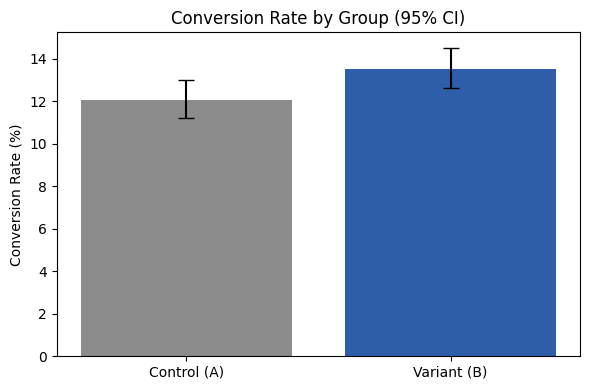

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
rates = [p_A*100, p_B*100]
err_low = [(p_A-ci_A[0])*100, (p_B-ci_B[0])*100]
err_high = [(ci_A[1]-p_A)*100, (ci_B[1]-p_B)*100]
ax.bar(["Control (A)","Variant (B)"], rates, yerr=[err_low, err_high], capsize=6,
       color=["#8C8C8C","#2E5EAA"])
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Group (95% CI)")
plt.tight_layout()
plt.show()

## 9. Decision Summary

| Metric | Value |
|---|---|
| Alpha | 0.05 |
| Two-sided p-value | see output above |
| Statistically significant? | Yes if p < 0.05 |
| 95% CI excludes zero? | Yes → genuine lift |

**Decision rule:** If p-value < 0.05 **and** the lift is positive → **Launch Variant B**. Otherwise → **Keep Control A** (or extend the test to reach the required sample size).

In [14]:
alpha = 0.05
significant = p_val_two_sided < alpha
decision = "LAUNCH VARIANT B" if (significant and diff > 0) else "KEEP CONTROL A"
print(f"Significant at alpha={alpha}: {significant}")
print(f"Decision: {decision}")

Significant at alpha=0.05: True
Decision: LAUNCH VARIANT B


## 10. Executive Decision Memo (Launch Variant vs. Keep Control)

### Summary

We tested a redesigned checkout flow (Variant B) against the existing checkout flow (Control A) across 10,000 sessions, split evenly between groups (5,000 each). Variant B converted at **13.54%**, compared to **12.08%** for Control — an absolute lift of **1.46 percentage points** and a relative lift of **12.1%**.

This difference is statistically significant: the two-sided Z-test returned **p = 0.0289** (below the 0.05 threshold), and the Chi-Square test of independence confirms this exactly (χ² = Z² = 4.7712, identical p-value). The 95% confidence interval for the lift, **[0.15%, 2.77%]**, excludes zero — meaning we can rule out "no difference" as an explanation with 95% confidence.

### Recommendation

**LAUNCH VARIANT B.**

The evidence supports rolling out the redesigned checkout flow to 100% of traffic. The improvement is unlikely to be due to random chance, and even the conservative lower bound of the confidence interval (+0.15%) represents a meaningful gain once applied at scale across full site traffic.

### Caveats & Risks

- **Underpowered going in:** The a-priori power analysis (80% power, α = 0.05) called for approximately **5,581 sessions per group** to reliably detect the assumed effect size. The actual sample (5,000/group) fell slightly short of this. The test still reached significance on the data collected, but this margin is thin enough that a short confirmatory hold-out test is advisable before committing fully.
- **Small standardized effect size:** Cohen's h = 0.044, which falls in the "small effect" range by conventional benchmarks. This doesn't undercut the statistical validity of the result, but it does mean the per-user behavioral shift is modest — the business-relevant framing (12.1% relative lift) is more meaningful than the standardized effect size alone.
- **Untested assumptions:** This analysis assumes independent, non-overlapping sessions with no novelty effect, seasonality bias, or channel-mix imbalance between groups. A sample ratio mismatch (SRM) check and a segment-level breakdown (by device type and traffic source) are recommended before final sign-off, since an uneven split or biased routing could distort the apparent lift.

### Next Steps

1. Ramp Variant B to 100% of checkout traffic on a phased schedule (e.g., 50% → 100% over one week), monitoring conversion rate, average order value (AOV), and error rates in real time.
2. Run a guardrail check on downstream metrics — refund rate and cart abandonment at the payment step — for two weeks post-launch to confirm the lift isn't offset elsewhere in the funnel.
3. Archive the Control A configuration for at least one full business cycle in case a rollback is needed.

---